In [12]:
# importation of evaluation tools
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Loading of the data

df = pd.read_csv("../data/processed/ad_click_clean_featured_engineered.csv")

df_encoded = pd.get_dummies(
    df,
    columns=["gender", "device_type", "ad_position", "time_of_day"],
    drop_first=True

)

X = df_encoded.drop("click", axis=1)
y = df_encoded["click"]

In [14]:
# Rebuilding of the model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [15]:
# Accuracy of the trained models
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6480


In [16]:
# Here we perform Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[   1,  704],
       [   0, 1295]])

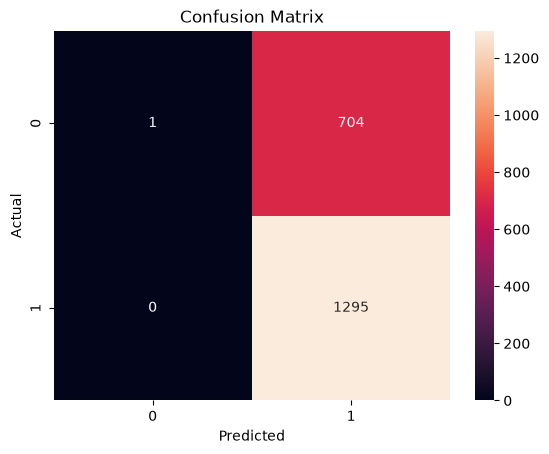

In [17]:
# Visualization

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
# Precision, Recall, F1
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       705
           1       0.65      1.00      0.79      1295

    accuracy                           0.65      2000
   macro avg       0.82      0.50      0.39      2000
weighted avg       0.77      0.65      0.51      2000



In [19]:
# ROC - AUC 

auc = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.5401


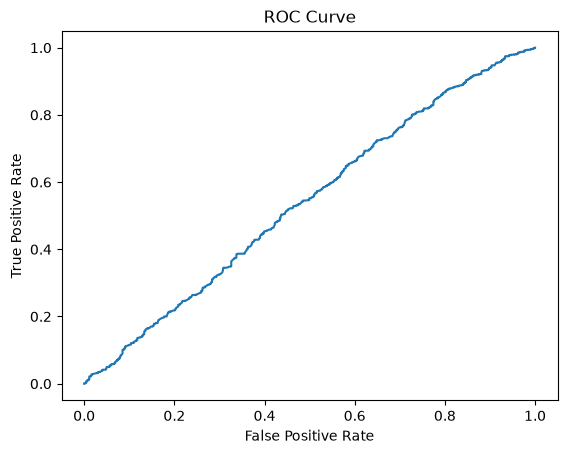

In [20]:
# ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()